In [ ]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import cv2
import matplotlib.pyplot as plt

import trackpy as tp
from tqdm import tqdm


In [ ]:
PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "data" / "raw"
OUT_DIR = PROJECT_DIR / "data" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
videos = sorted(RAW_DIR.glob("*.mp4"))
print("Found videos:", len(videos))
for v in videos[:10]:
    print(" -", v.name)

# picking the one with 1 particle
video_path = videos[7]
print("Using video:", video_path.name)

Found videos: 11
 - vid_001.mp4
 - vid_002.mp4
 - vid_003.mp4
 - vid_004.mp4
 - vid_005.mp4
 - vid_006.mp4
 - vid_007.mp4
 - vid_008.mp4
 - vid_009.mp4
 - vid_010.mp4
Using video: vid_008.mp4


In [ ]:
cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration_sec = frame_count / fps if fps else float("nan")
cap.release()

file_size_mb = video_path.stat().st_size / (1024**2)

summary = pd.DataFrame([{
    "video_name": video_path.name,
    "fps": fps,
    "frame_count": frame_count,
    "duration_sec": duration_sec,
    "width": width,
    "height": height,
    "file_size_mb": file_size_mb
}])

summary

,video_name,fps,frame_count,duration_sec,width,height,file_size_mb
0,vid_008.mp4,33.0,2218,67.212121,1440,1080,46.571592


In [ ]:
print("Current video_path:", video_path)


Current video_path: C:\Users\milli\Desktop\capstone_project\data\raw\vid_008.mp4


In [ ]:
all_stats = []

for video_pth in videos:
    cap = cv2.VideoCapture(str(video_pth))

    if not cap.isOpened():
        print(f"Could not open {video_pth.name}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration_sec = frame_count / fps if fps else float("nan")

    cap.release()

    file_size_mb = video_pth.stat().st_size / (1024**2)

    all_stats.append({
        "video_name": video_pth.name,
        "fps": fps,
        "frame_count": frame_count,
        "duration_sec": duration_sec,
        "width": width,
        "height": height,
        "file_size_mb": file_size_mb
    })

general_stats = pd.DataFrame(all_stats)

general_stats

,video_name,fps,frame_count,duration_sec,width,height,file_size_mb
0,vid_001.mp4,33.0,4554,138.000000,1440,1080,101.445526
1,vid_002.mp4,33.0,7635,231.363636,1440,1080,175.152750
2,vid_003.mp4,33.0,1617,49.000000,1440,1080,36.761576
3,vid_004.mp4,33.0,2425,73.484848,1440,1080,5.189418
4,vid_005.mp4,33.0,1363,41.303030,1440,1080,2.731940
5,vid_006.mp4,33.0,1117,33.848485,1440,1080,23.610138
6,vid_007.mp4,33.0,4573,138.575758,1440,1080,101.517474
7,vid_008.mp4,33.0,2218,67.212121,1440,1080,46.571592
8,vid_009.mp4,33.0,2029,61.484848,1440,1080,44.617383
9,vid_010.mp4,33.0,1007,30.515152,1440,1080,22.349866


In [ ]:
print("Current video_path:", video_path)

Current video_path: C:\Users\milli\Desktop\capstone_project\data\raw\vid_008.mp4


In [ ]:
general_stats.to_csv(OUT_DIR / "general_statistics.csv", index=False)

In [ ]:
cap = cv2.VideoCapture(str(video_path))
ret, frame0 = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read the first frame from the selected video.")

print("Frame shape (H, W, C):", frame0.shape)


Frame shape (H, W, C): (1080, 1440, 3)


In [ ]:
print("Current video_path:", video_path)

Current video_path: C:\Users\milli\Desktop\capstone_project\data\raw\vid_008.mp4


In [ ]:
roi = cv2.selectROI(
    "Select ROI (laser region) and press ENTER",
    frame0,
    fromCenter=False,
    showCrosshair=True
)
cv2.destroyAllWindows()

roi = tuple(map(int, roi))  # (x, y, w, h)
print("ROI (x, y, w, h):", roi)

ROI (x, y, w, h): (550, 371, 363, 302)


In [ ]:
print("Current video_path:", video_path)

Current video_path: C:\Users\milli\Desktop\capstone_project\data\raw\vid_008.mp4


In [ ]:
x, y, w, h = roi
cropped0 = frame0[y:y+h, x:x+w]

cv2.imshow("Cropped ROI (frame 0)", cropped0)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
print("Current video_path:", video_path)

Current video_path: C:\Users\milli\Desktop\capstone_project\data\raw\vid_008.mp4


In [ ]:
cap = cv2.VideoCapture(str(video_path))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

check_frames = [0, total // 2, max(total - 1, 0)]
print("Checking frames:", check_frames)

x, y, w, h = roi

for fidx in check_frames:
    cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
    ret, frame = cap.read()
    if not ret:
        print("Could not read frame", fidx)
        continue

    cropped = frame[y:y+h, x:x+w]
    cv2.imshow(f"ROI @ frame {fidx}", cropped)
    cv2.waitKey(0)

cap.release()
cv2.destroyAllWindows()

Checking frames: [0, 1109, 2217]


In [ ]:
print("Current video_path:", video_path)

Current video_path: C:\Users\milli\Desktop\capstone_project\data\raw\vid_008.mp4


In [ ]:
roi_table_path = OUT_DIR / "roi_table.csv"

# Load existing table if it exists, else create a new one
if roi_table_path.exists():
    roi_df = pd.read_csv(roi_table_path)
else:
    roi_df = pd.DataFrame({
        "video_name": [v.name for v in videos],
        "roi_x": [pd.NA]*len(videos),
        "roi_y": [pd.NA]*len(videos),
        "roi_w": [pd.NA]*len(videos),
        "roi_h": [pd.NA]*len(videos),
    })

# Ensure current video's ROI is saved (roi must already exist as (x,y,w,h))
x, y, w, h = map(int, roi)
roi_df.loc[roi_df["video_name"] == video_path.name, ["roi_x","roi_y","roi_w","roi_h"]] = [x, y, w, h]
roi_df.to_csv(roi_table_path, index=False)

print("ROI already saved for:", video_path.name)
roi_df.head()

ROI already saved for: vid_008.mp4


,video_name,roi_x,roi_y,roi_w,roi_h
0,vid_001.mp4,<NA>,<NA>,<NA>,<NA>
1,vid_002.mp4,<NA>,<NA>,<NA>,<NA>
2,vid_003.mp4,<NA>,<NA>,<NA>,<NA>
3,vid_004.mp4,<NA>,<NA>,<NA>,<NA>
4,vid_005.mp4,<NA>,<NA>,<NA>,<NA>


In [ ]:
def select_roi_first_frame(vpath):
    """Open first frame and let user select ROI. Returns (x,y,w,h) as ints."""
    cap = cv2.VideoCapture(str(vpath))
    ret, frame0 = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError(f"Could not read first frame of {vpath.name}")

    r = cv2.selectROI(
        f"Select ROI for {vpath.name} (ENTER=confirm, ESC=cancel)",
        frame0,
        fromCenter=False,
        showCrosshair=True
    )
    cv2.destroyAllWindows()
    return tuple(map(int, r))

# Process all videos except the one you already did
for v in videos:
    if v.name == video_path.name:
        continue  # skip vid_008 (already done)

    row = roi_df.loc[roi_df["video_name"] == v.name]
    if not row.empty and pd.notna(row.iloc[0]["roi_x"]):
        print("Skipping (ROI already exists):", v.name)
        continue

    print("\nSelecting ROI for:", v.name)
    r = select_roi_first_frame(v)
    print("ROI:", r)

    # If user cancels selection, ROI may be (0,0,0,0). Handle that:
    if r[2] == 0 or r[3] == 0:
        print("Skipped (ROI canceled) for:", v.name)
        continue

    roi_df.loc[roi_df["video_name"] == v.name, ["roi_x","roi_y","roi_w","roi_h"]] = list(r)

    # Save after each video so you can stop anytime
    roi_df.to_csv(roi_table_path, index=False)
    print("Saved ROI for:", v.name)

print("\nDone. ROI table saved to:", roi_table_path)



Selecting ROI for: vid_001.mp4
ROI: (565, 374, 328, 275)
Saved ROI for: vid_001.mp4

Selecting ROI for: vid_002.mp4
ROI: (562, 381, 336, 263)
Saved ROI for: vid_002.mp4

Selecting ROI for: vid_003.mp4
ROI: (542, 354, 408, 344)
Saved ROI for: vid_003.mp4

Selecting ROI for: vid_004.mp4
ROI: (540, 355, 381, 329)
Saved ROI for: vid_004.mp4

Selecting ROI for: vid_005.mp4
ROI: (562, 368, 353, 312)
Saved ROI for: vid_005.mp4

Selecting ROI for: vid_006.mp4
ROI: (586, 372, 313, 280)
Saved ROI for: vid_006.mp4

Selecting ROI for: vid_007.mp4
ROI: (582, 374, 325, 298)
Saved ROI for: vid_007.mp4

Selecting ROI for: vid_009.mp4
ROI: (572, 371, 325, 301)
Saved ROI for: vid_009.mp4

Selecting ROI for: vid_010.mp4
ROI: (589, 385, 301, 276)
Saved ROI for: vid_010.mp4

Selecting ROI for: vid_011.mp4
ROI: (569, 366, 335, 288)
Saved ROI for: vid_011.mp4

Done. ROI table saved to: C:\Users\milli\Desktop\capstone_project\data\outputs\roi_table.csv


In [ ]:
roi_df = pd.read_csv(OUT_DIR / "roi_table.csv")

def get_roi_for(video_name: str):
    row = roi_df.loc[roi_df["video_name"] == video_name].iloc[0]
    return int(row["roi_x"]), int(row["roi_y"]), int(row["roi_w"]), int(row["roi_h"])

roi = get_roi_for(video_path.name)
print("Using ROI:", roi)

Using ROI: (550, 371, 363, 302)


In [ ]:
def cropped_frame_generator(video_path, roi, max_frames=None):
    """Yield (frame_idx, cropped_bgr_frame)"""
    x, y, w, h = roi
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open {video_path}")

    idx = 0
    while True:
        if max_frames is not None and idx >= max_frames:
            break

        ret, frame = cap.read()
        if not ret:
            break

        cropped = frame[y:y+h, x:x+w]
        yield idx, cropped
        idx += 1

    cap.release()

In [ ]:
idx, cropped0 = next(cropped_frame_generator(video_path, roi, max_frames=1))
cv2.imshow("Cropped ROI preview", cropped0)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
print("Current video_path:", video_path)

Current video_path: C:\Users\milli\Desktop\capstone_project\data\raw\vid_008.mp4


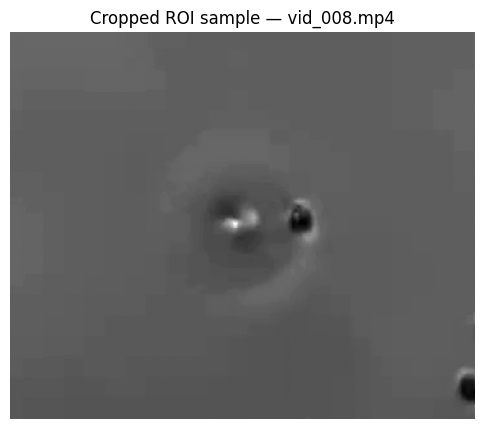

Cropped shape: (302, 363)


In [ ]:
# ROI should already be loaded for this video (x,y,w,h)
x, y, w, h = roi

cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read a frame for tuning.")

cropped = frame[y:y+h, x:x+w]
gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title(f"Cropped ROI sample — {video_path.name}")
plt.axis("off")
plt.show()

print("Cropped shape:", gray.shape)

In [ ]:
# blur median

# auto encoder-ov latent attribute representation pordzel

In [ ]:
print("Gray min/max:", int(gray.min()), int(gray.max()), "mean:", float(gray.mean()))

Gray min/max: 58 255 mean: 129.48554175104445


In [ ]:
gray_for_tp = 255 - gray


In [ ]:
diameters = [11, 15, 19, 23, 27, 31]
for d in diameters:
    f = tp.locate(gray_for_tp, diameter=d, minmass=250)  # low minmass for now
    n = 0 if f is None else len(f)
    print(f"diameter={d:2d} -> detections={n}")


diameter=11 -> detections=5
diameter=15 -> detections=8
diameter=19 -> detections=19
diameter=23 -> detections=31
diameter=27 -> detections=26
diameter=31 -> detections=19


In [ ]:
D = 11
for mm in [100, 200, 300, 400, 600, 800, 1000]:
    f = tp.locate(gray_for_tp, diameter=D, minmass=mm)
    print(f"minmass={mm:4d} -> detections={0 if f is None else len(f)}")


minmass= 100 -> detections=17
minmass= 200 -> detections=6
minmass= 300 -> detections=5
minmass= 400 -> detections=4
minmass= 600 -> detections=3
minmass= 800 -> detections=3
minmass=1000 -> detections=1


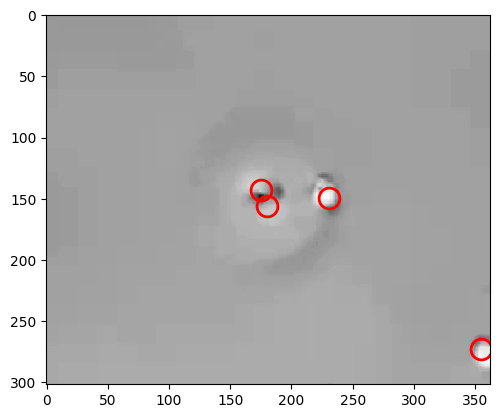

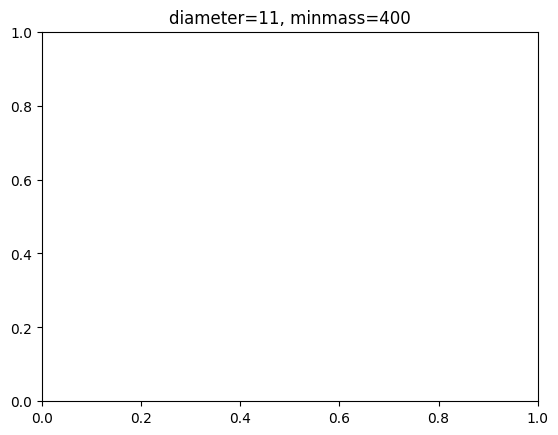

In [ ]:
MM = 400  # example
f = tp.locate(gray_for_tp, diameter=D, minmass=MM)
tp.annotate(f, gray_for_tp);
plt.title(f"diameter={D}, minmass={MM}")
plt.show()


In [ ]:
N = 300  # test

cap = cv2.VideoCapture(str(video_path))
detections = []
frame_idx = 0

while True:
    if N is not None and frame_idx >= N:
        break

    ret, frame = cap.read()
    if not ret:
        break

    cropped = frame[y:y+h, x:x+w]
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    gray_for_tp = gray  # change to 255-gray if needed

    f = tp.locate(gray_for_tp, diameter=D, minmass=MM)
    if f is not None and len(f) > 0:
        f = f[["x", "y", "mass", "size", "ecc"]].copy()
        f["frame"] = frame_idx
        detections.append(f)

    frame_idx += 1

cap.release()

det_df = pd.concat(detections, ignore_index=True) if detections else pd.DataFrame()
print("Total detections rows:", len(det_df))
det_df.head()

Total detections rows: 1751


,x,y,mass,size,ecc,frame
0,226.418194,132.109651,764.006557,2.913369,0.428652,0
1,189.161955,144.264201,1000.264552,3.142204,0.133632,0
2,174.732173,149.175322,1745.507891,2.684100,0.151657,0
3,237.079094,154.278128,711.680961,3.160633,0.363138,0
4,353.809524,265.130789,810.253928,3.063846,0.333545,0


In [ ]:
counts = det_df.groupby("frame").size()
print("Frames processed:", frame_idx)
print("Median detections per frame:", int(counts.median()) if len(counts) else 0)
print("Min/Max detections per frame:", (int(counts.min()), int(counts.max())) if len(counts) else (0, 0))


Frames processed: 300
Median detections per frame: 6
Min/Max detections per frame: (4, 7)


In [ ]:
detections_csv = OUT_DIR / f"detections_{video_path.stem}.csv"
det_df.to_csv(detections_csv, index=False)
print("Saved:", detections_csv)


Saved: C:\Users\milli\Desktop\capstone_project\data\outputs\detections_vid_008.csv


In [ ]:
annot_path = OUT_DIR / f"annotated_{video_path.stem}.mp4"

cap_meta = cv2.VideoCapture(str(video_path))
fps = cap_meta.get(cv2.CAP_PROP_FPS) or 30
cap_meta.release()

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(annot_path), fourcc, fps, (w, h))

det_by_frame = {k: v for k, v in det_df.groupby("frame")}

cap = cv2.VideoCapture(str(video_path))
frame_idx = 0

while True:
    if N is not None and frame_idx >= N:
        break
    ret, frame = cap.read()
    if not ret:
        break

    cropped = frame[y:y+h, x:x+w]

    if frame_idx in det_by_frame:
        for _, row in det_by_frame[frame_idx].iterrows():
            cx, cy = int(row["x"]), int(row["y"])
            cv2.circle(cropped, (cx, cy), 5, (0, 255, 0), -1)

    writer.write(cropped)
    frame_idx += 1

cap.release()
writer.release()
print("Saved annotated video:", annot_path)


Saved annotated video: C:\Users\milli\Desktop\capstone_project\data\outputs\annotated_vid_008.mp4
